<h2>M, N, R & Curvatures display (from equator 'til pole)<h2>

In [1]:
from math import * 
import numpy as np
import matplotlib.pyplot as plt

In [2]:
e = 0.0818191908426215
a = 6378137

def M(phi):
    phi = np.deg2rad(phi)
    return ((a * (1 - e**2)) / ((1 - (e**2 * (sin(phi)**2)))) ** (3 / 2))

def N(phi):
    phi = np.deg2rad(phi)
    return ((a) / ((1 - (e**2 * (sin(phi)**2)))) ** (1 / 2))

def R(M, N):
    return ((M * N) ** (1 / 2))

In [3]:
phis = list(range(0, 91))
Ms = [M(phi) for phi in phis]
Ns = [N(phi) for phi in phis]
Rs = [R(M(phi), N(phi)) for phi in phis]

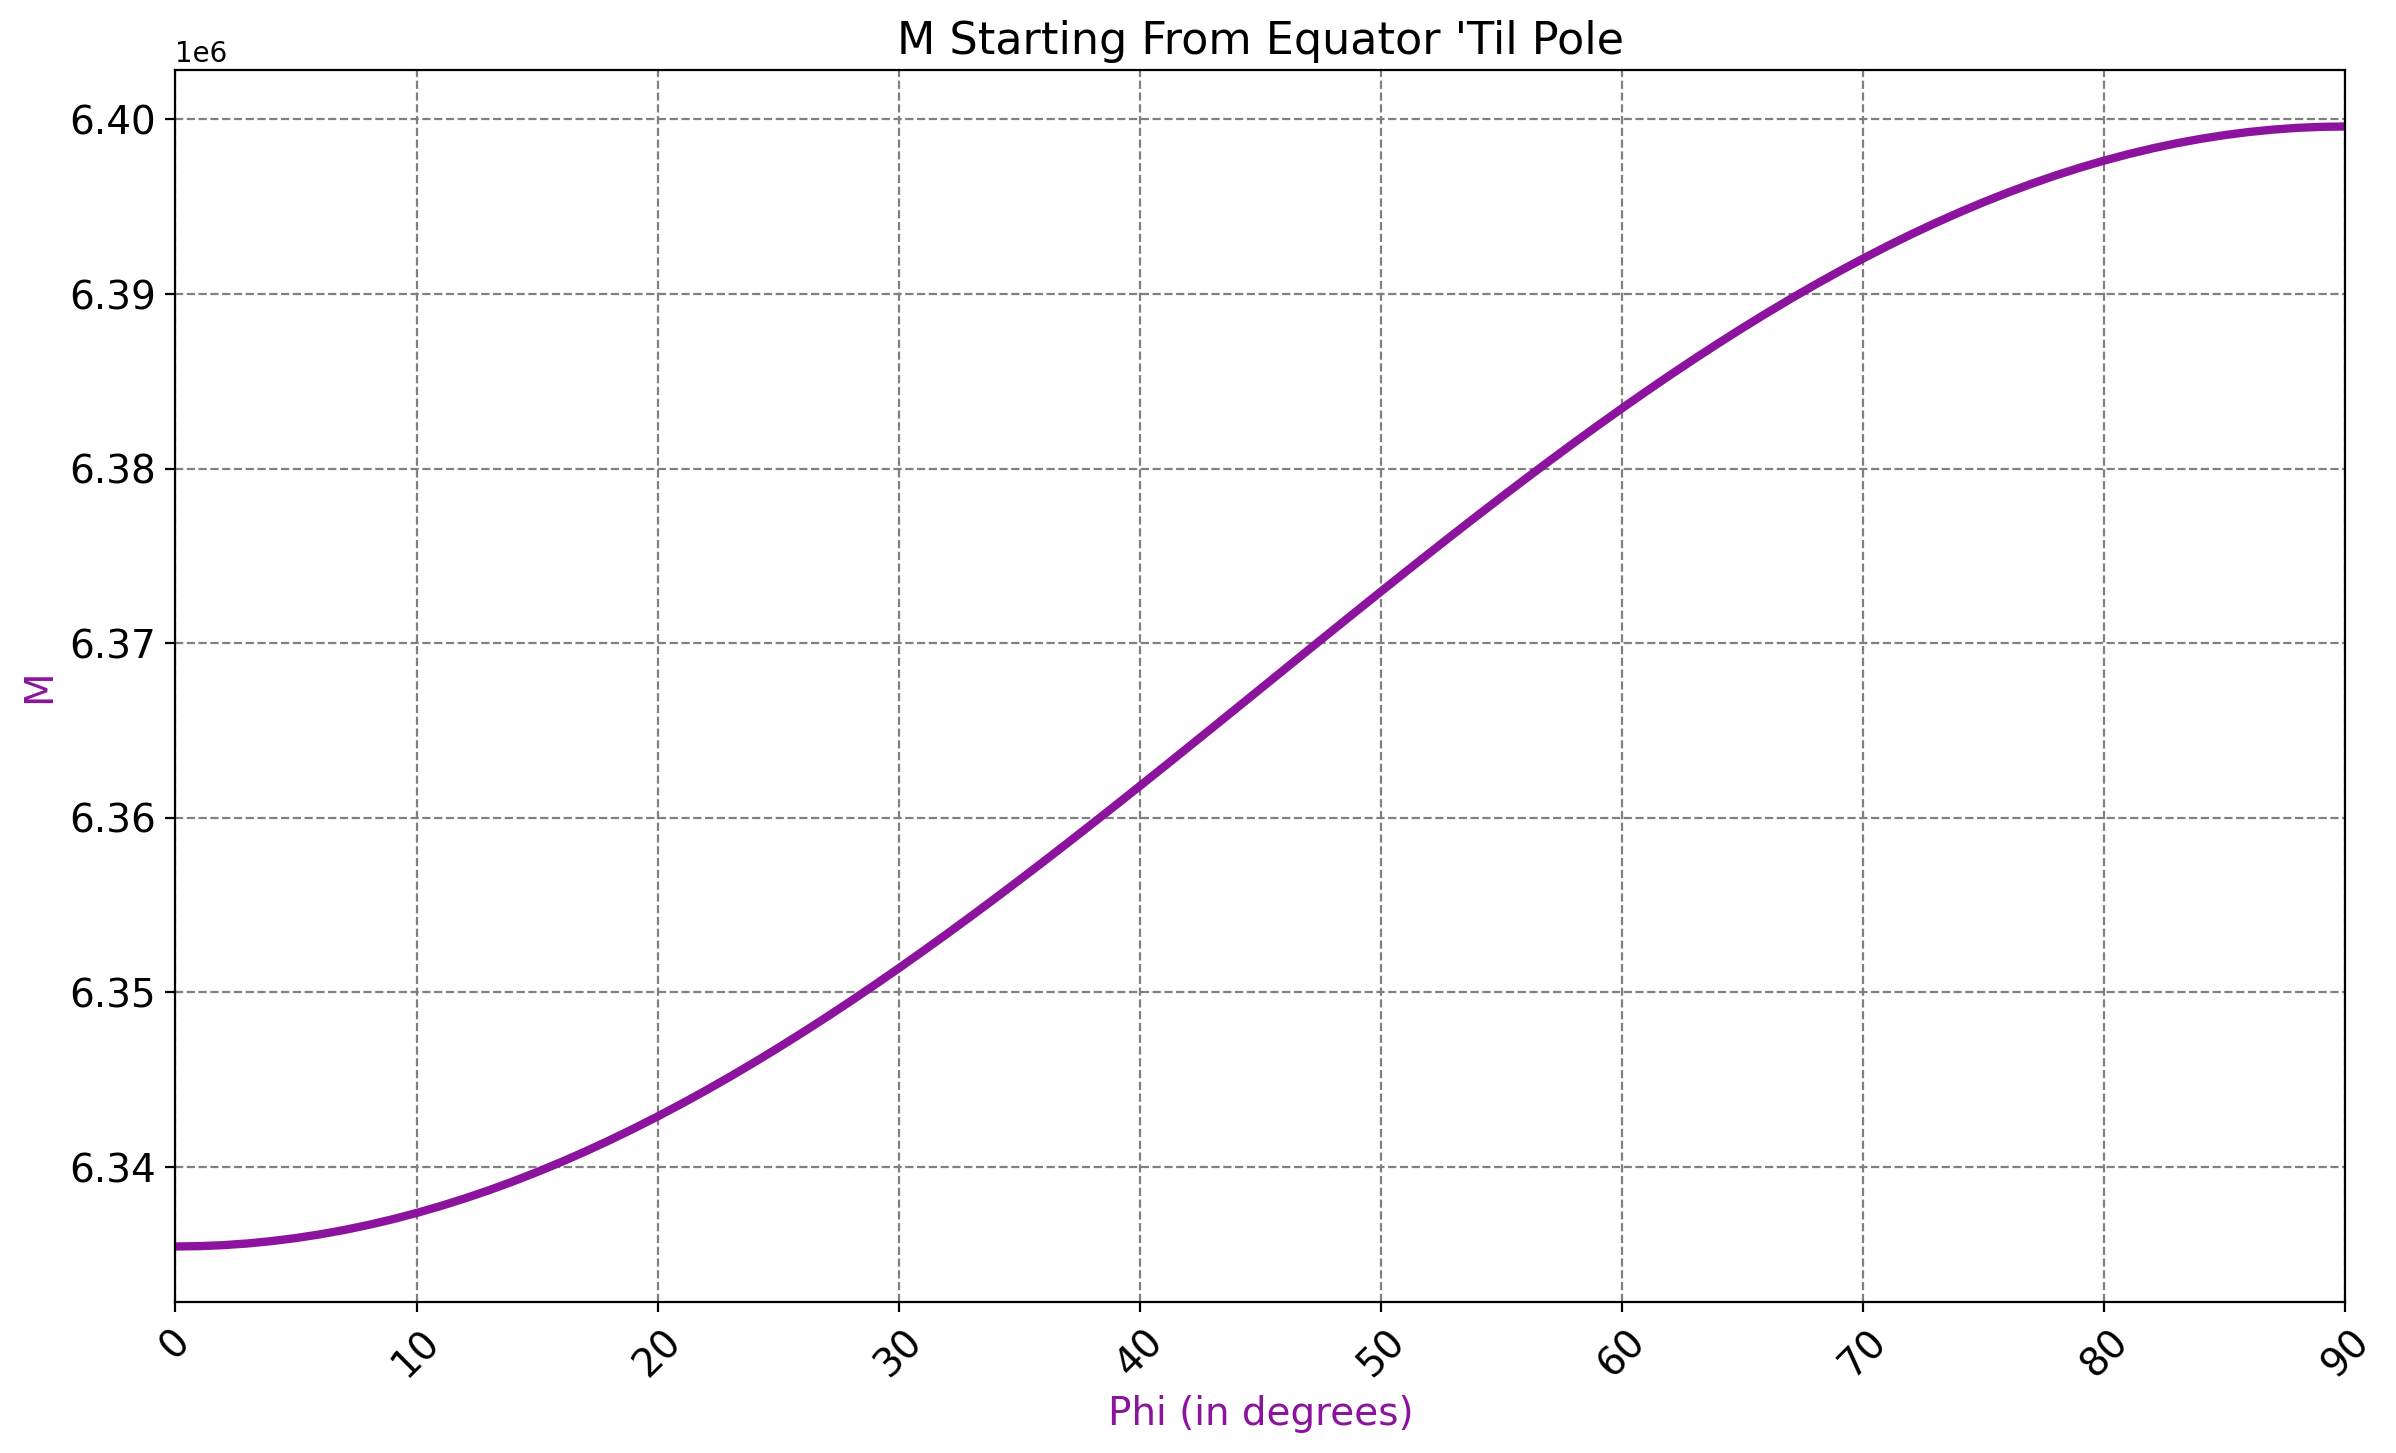

In [4]:
plt.figure(figsize=(14, 8), dpi=200)
plt.title("M Starting From Equator 'Til Pole", fontsize=16)
plt.yticks(fontsize=14)
plt.xticks(fontsize=14, rotation=45)

ax1 = plt.gca() # get current axis

ax1.set_ylabel("M", color="#8B139D", fontsize=14)
ax1.set_xlabel("Phi (in degrees)", color="#8B139D", fontsize=14)

ax1.set_xlim([min(phis), max(phis)])

ax1.grid(color="grey", linestyle="--")
ax1.plot(phis, Ms, 
         color="#8B139D", linewidth=3)

plt.show()

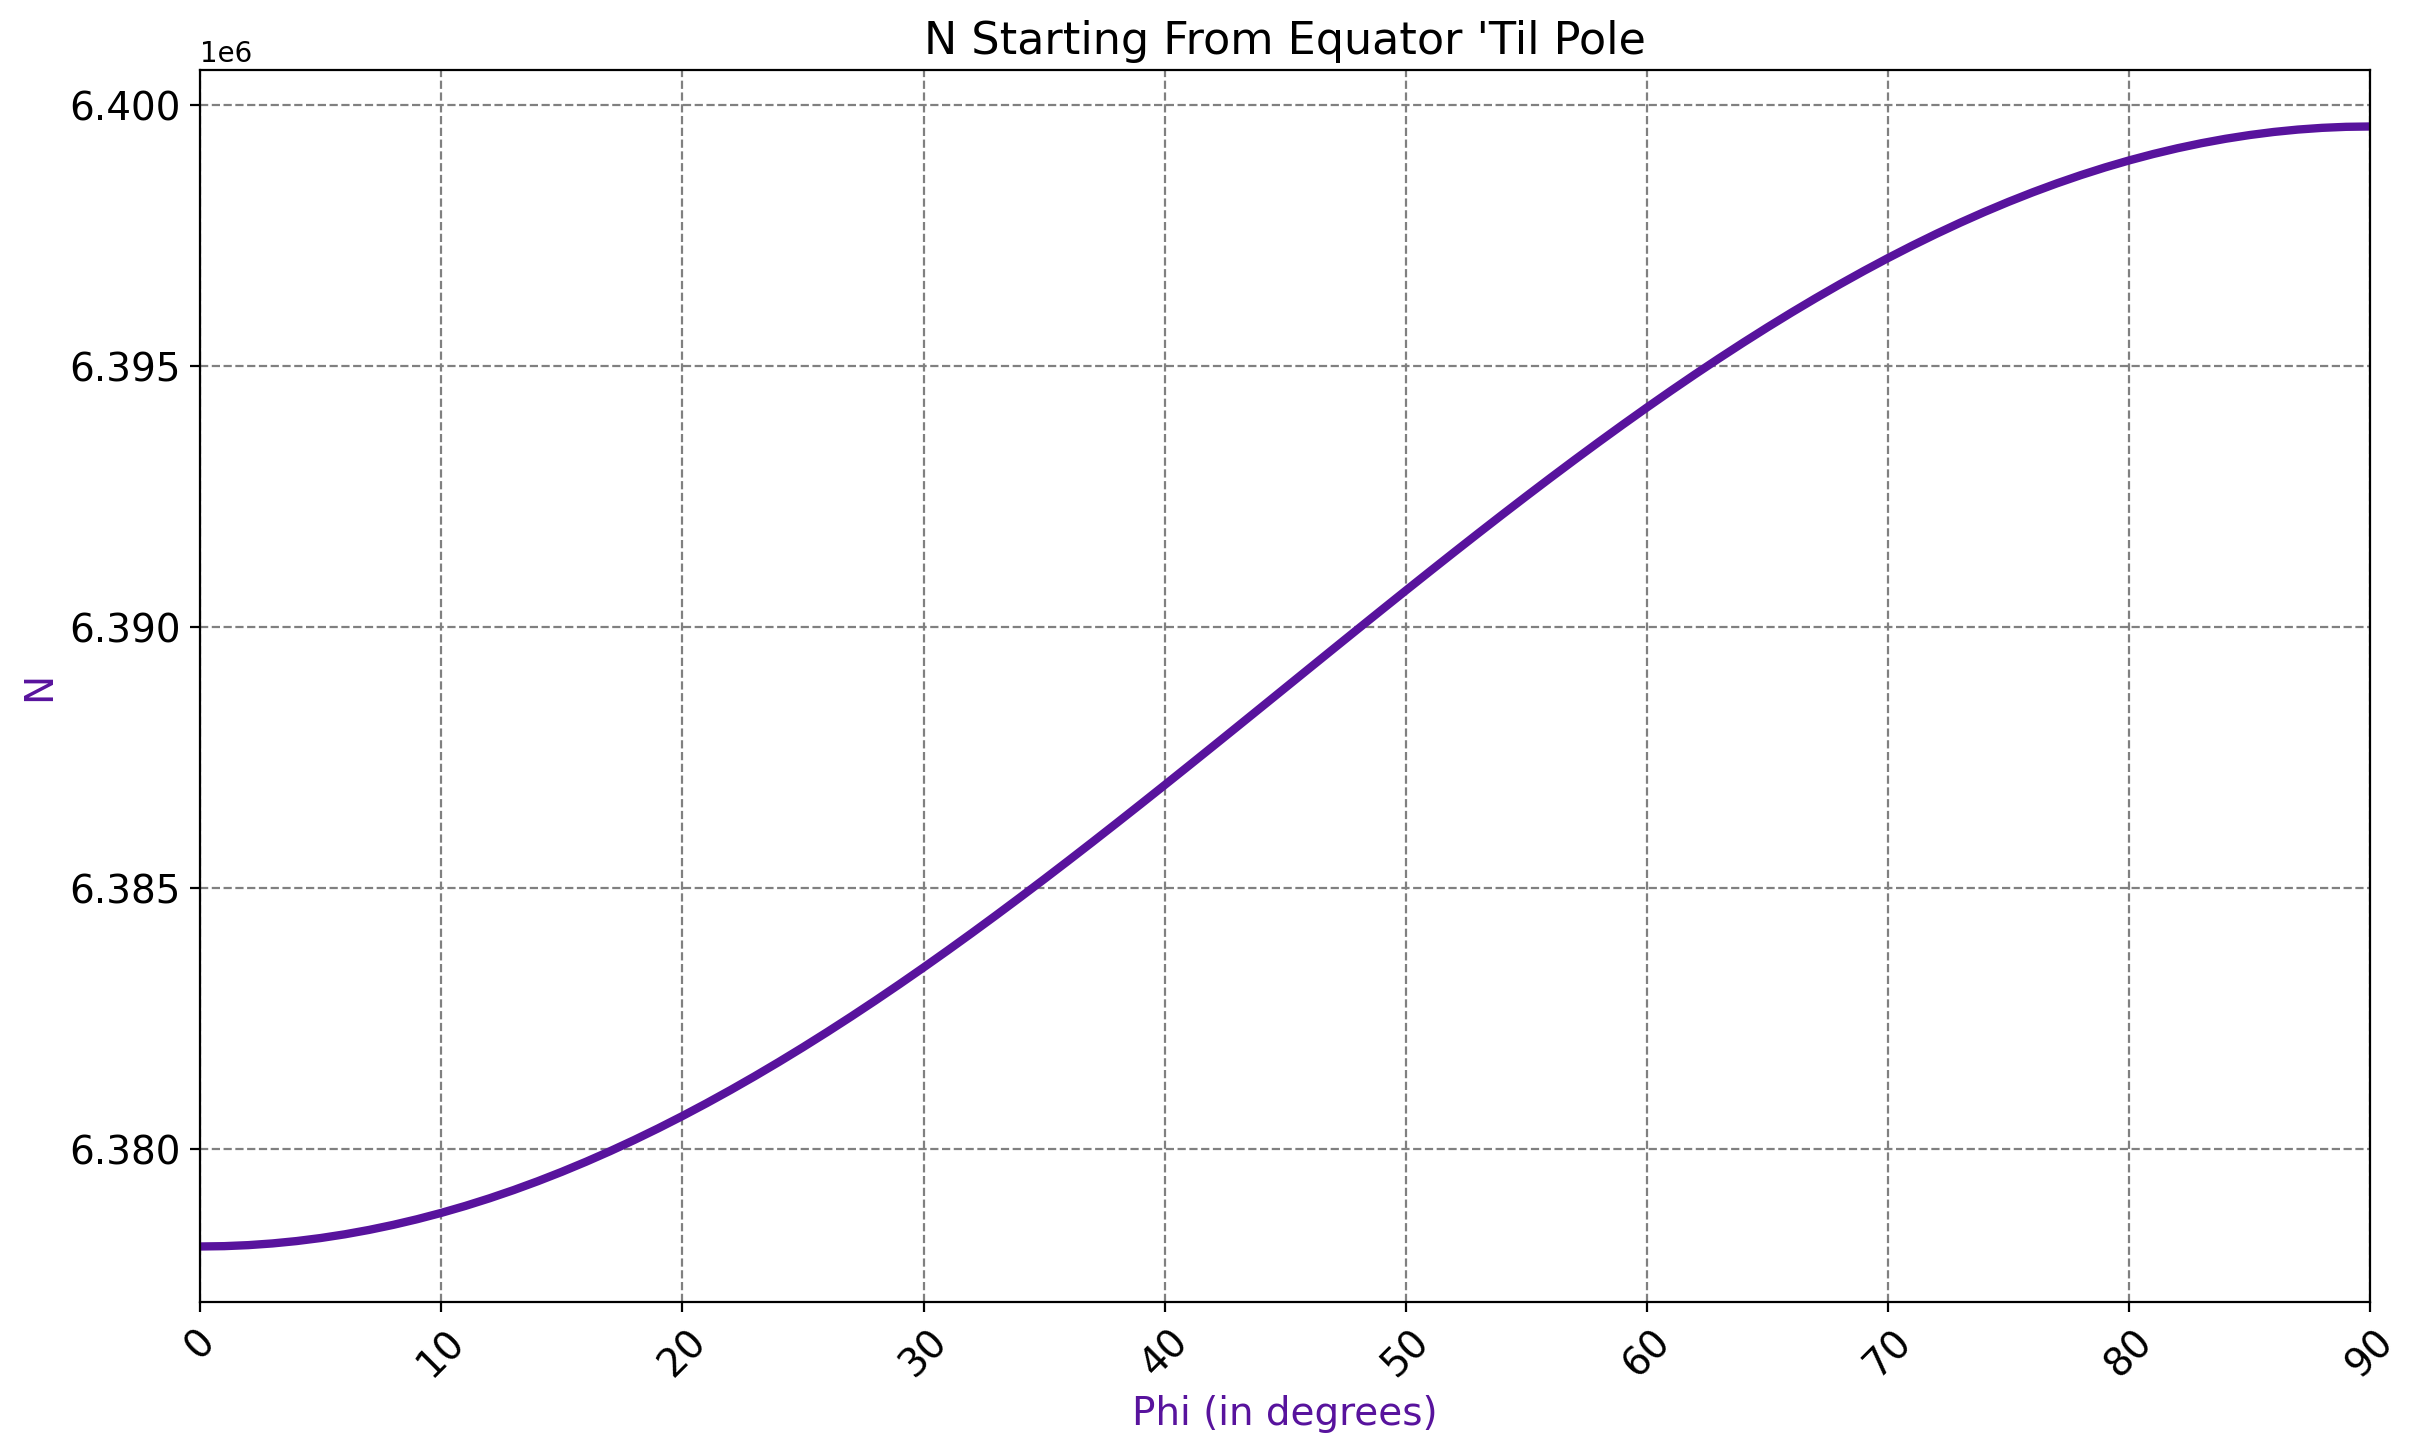

In [5]:
plt.figure(figsize=(14, 8), dpi=200)
plt.title("N Starting From Equator 'Til Pole", fontsize=16)
plt.yticks(fontsize=14)
plt.xticks(fontsize=14, rotation=45)

ax1 = plt.gca() # get current axis

ax1.set_ylabel("N", color="#58139D", fontsize=14)
ax1.set_xlabel("Phi (in degrees)", color="#58139D", fontsize=14)

ax1.set_xlim([min(phis), max(phis)])

ax1.grid(color="grey", linestyle="--")
ax1.plot(phis, Ns, 
         color="#58139D", linewidth=3)

plt.show()



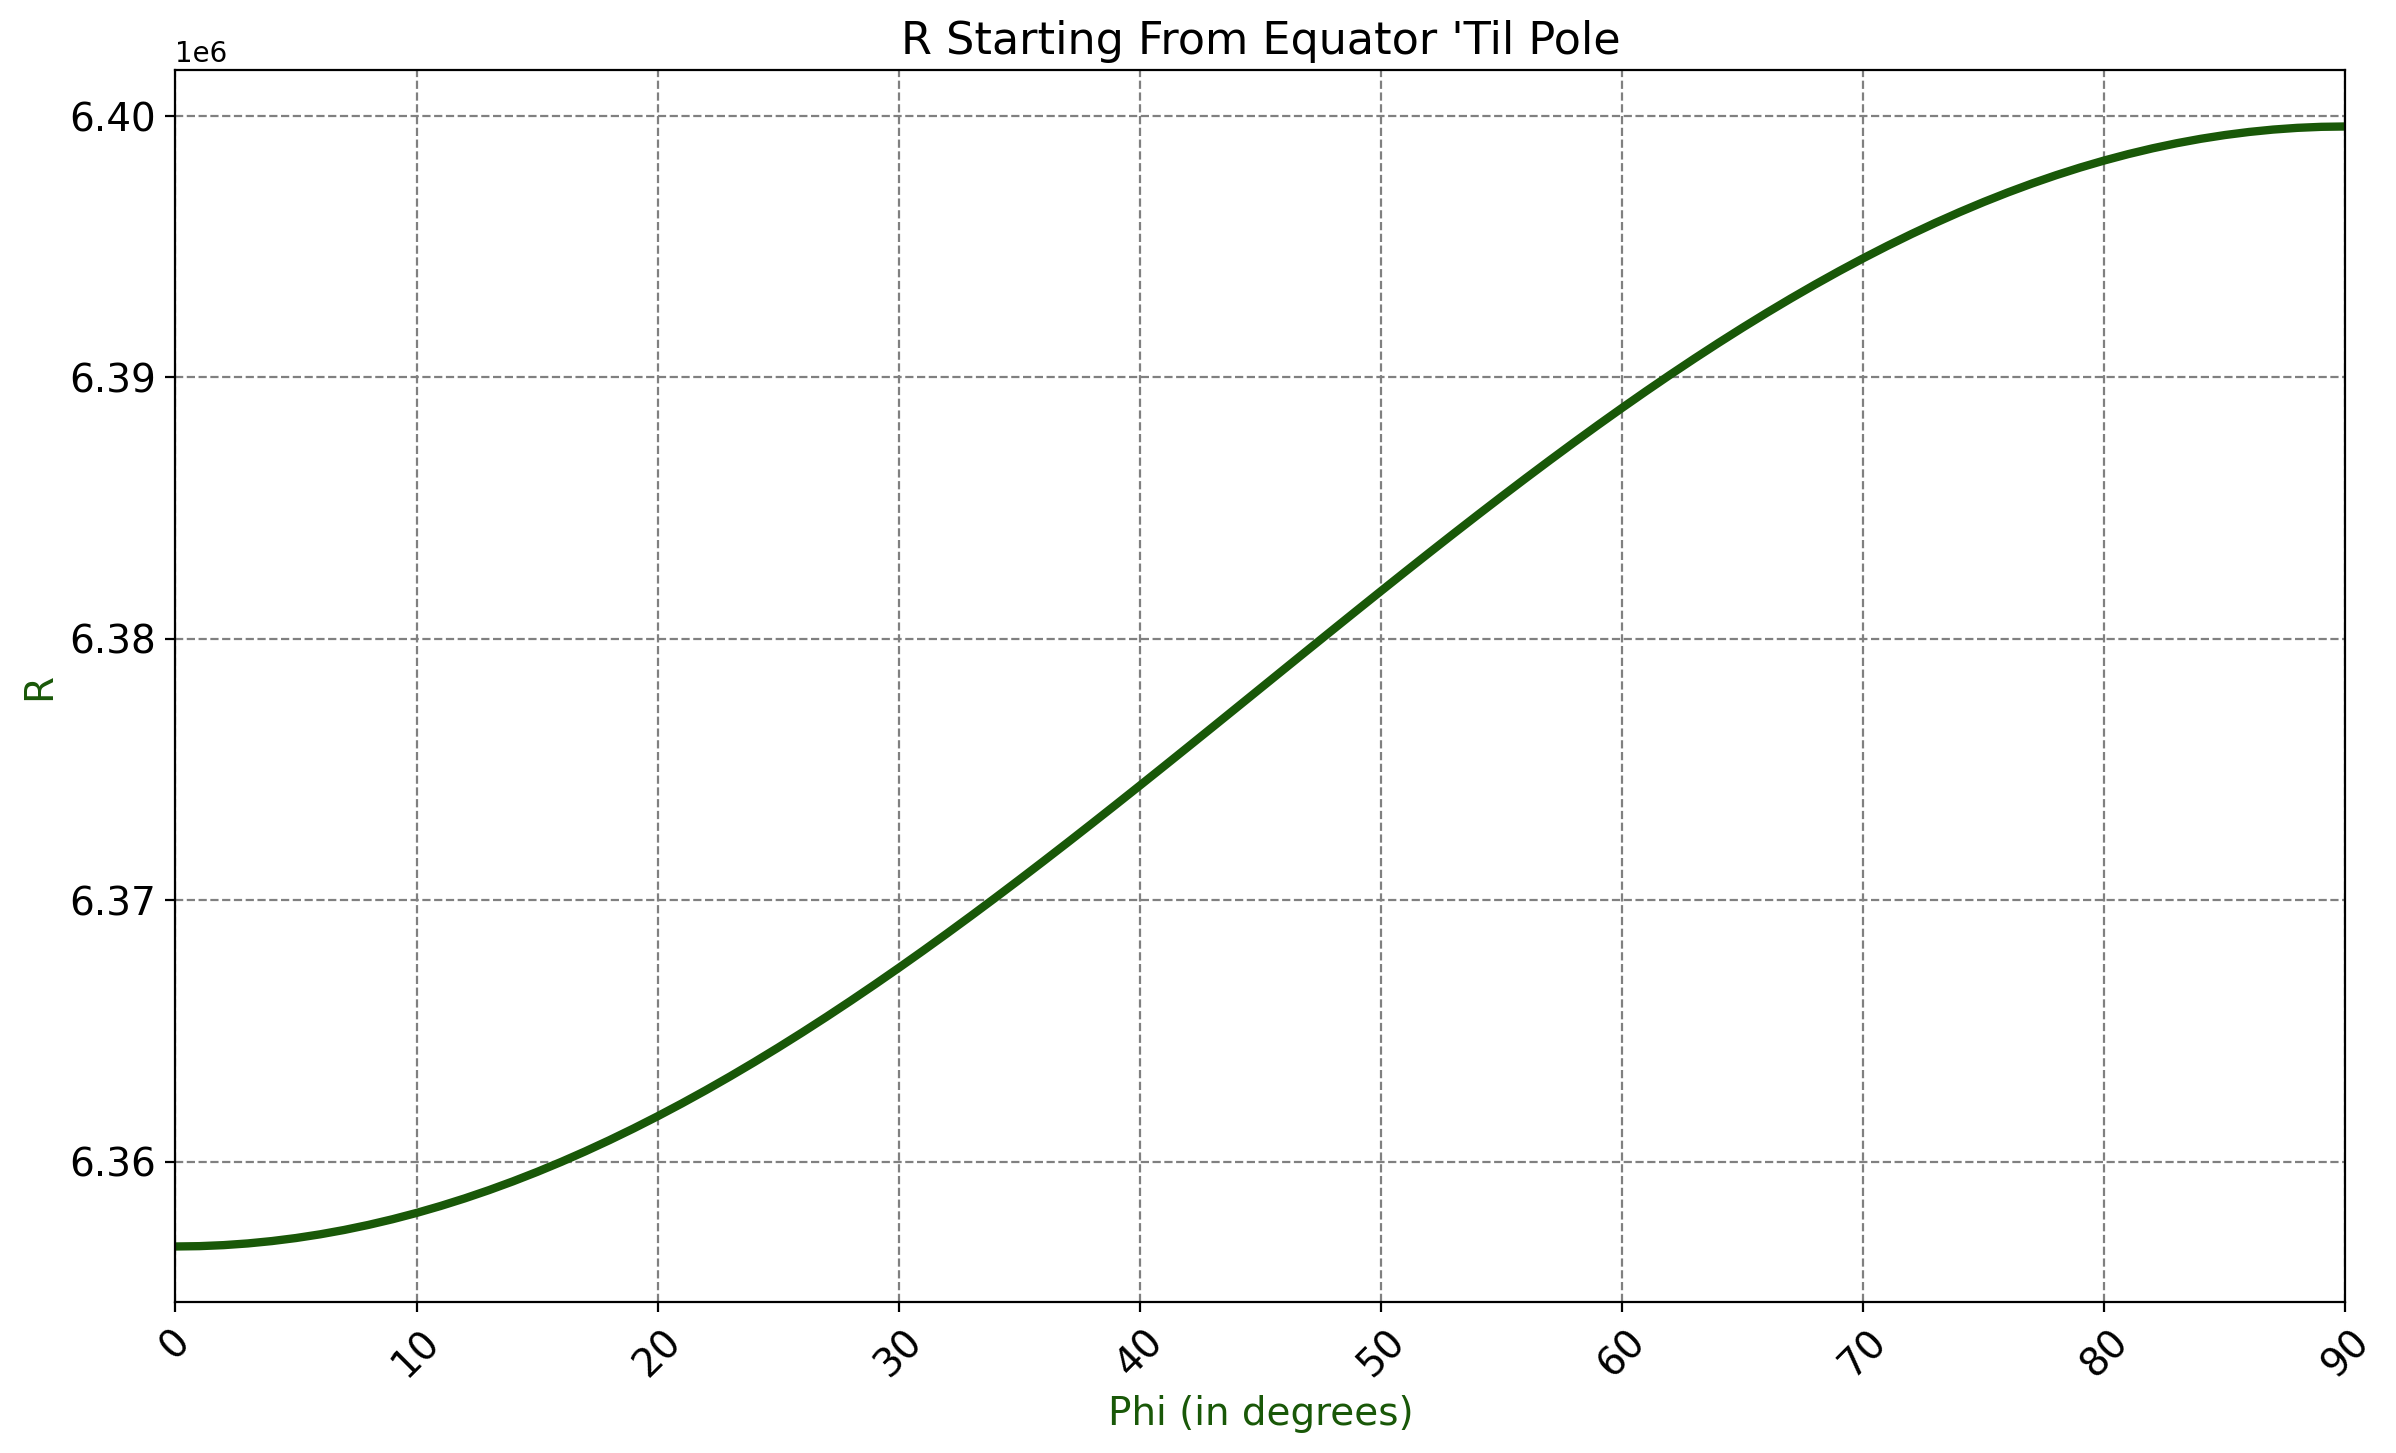

In [6]:
plt.figure(figsize=(14, 8), dpi=200)
plt.title("R Starting From Equator 'Til Pole", fontsize=16)
plt.yticks(fontsize=14)
plt.xticks(fontsize=14, rotation=45)

ax1 = plt.gca() # get current axis

ax1.set_ylabel("R", color="#195808", fontsize=14)
ax1.set_xlabel("Phi (in degrees)", color="#195808", fontsize=14)


ax1.set_xlim([min(phis), max(phis)])

ax1.grid(color="grey", linestyle="--")
ax1.plot(phis, Rs, 
         color="#195808", linewidth=3)

plt.show()


In [7]:
Curves_M = [1/M(phi) for phi in phis]
Curves_N = [1/N(phi) for phi in phis]
Curves_R = [1/(R(M(phi), N(phi))) for phi in phis]

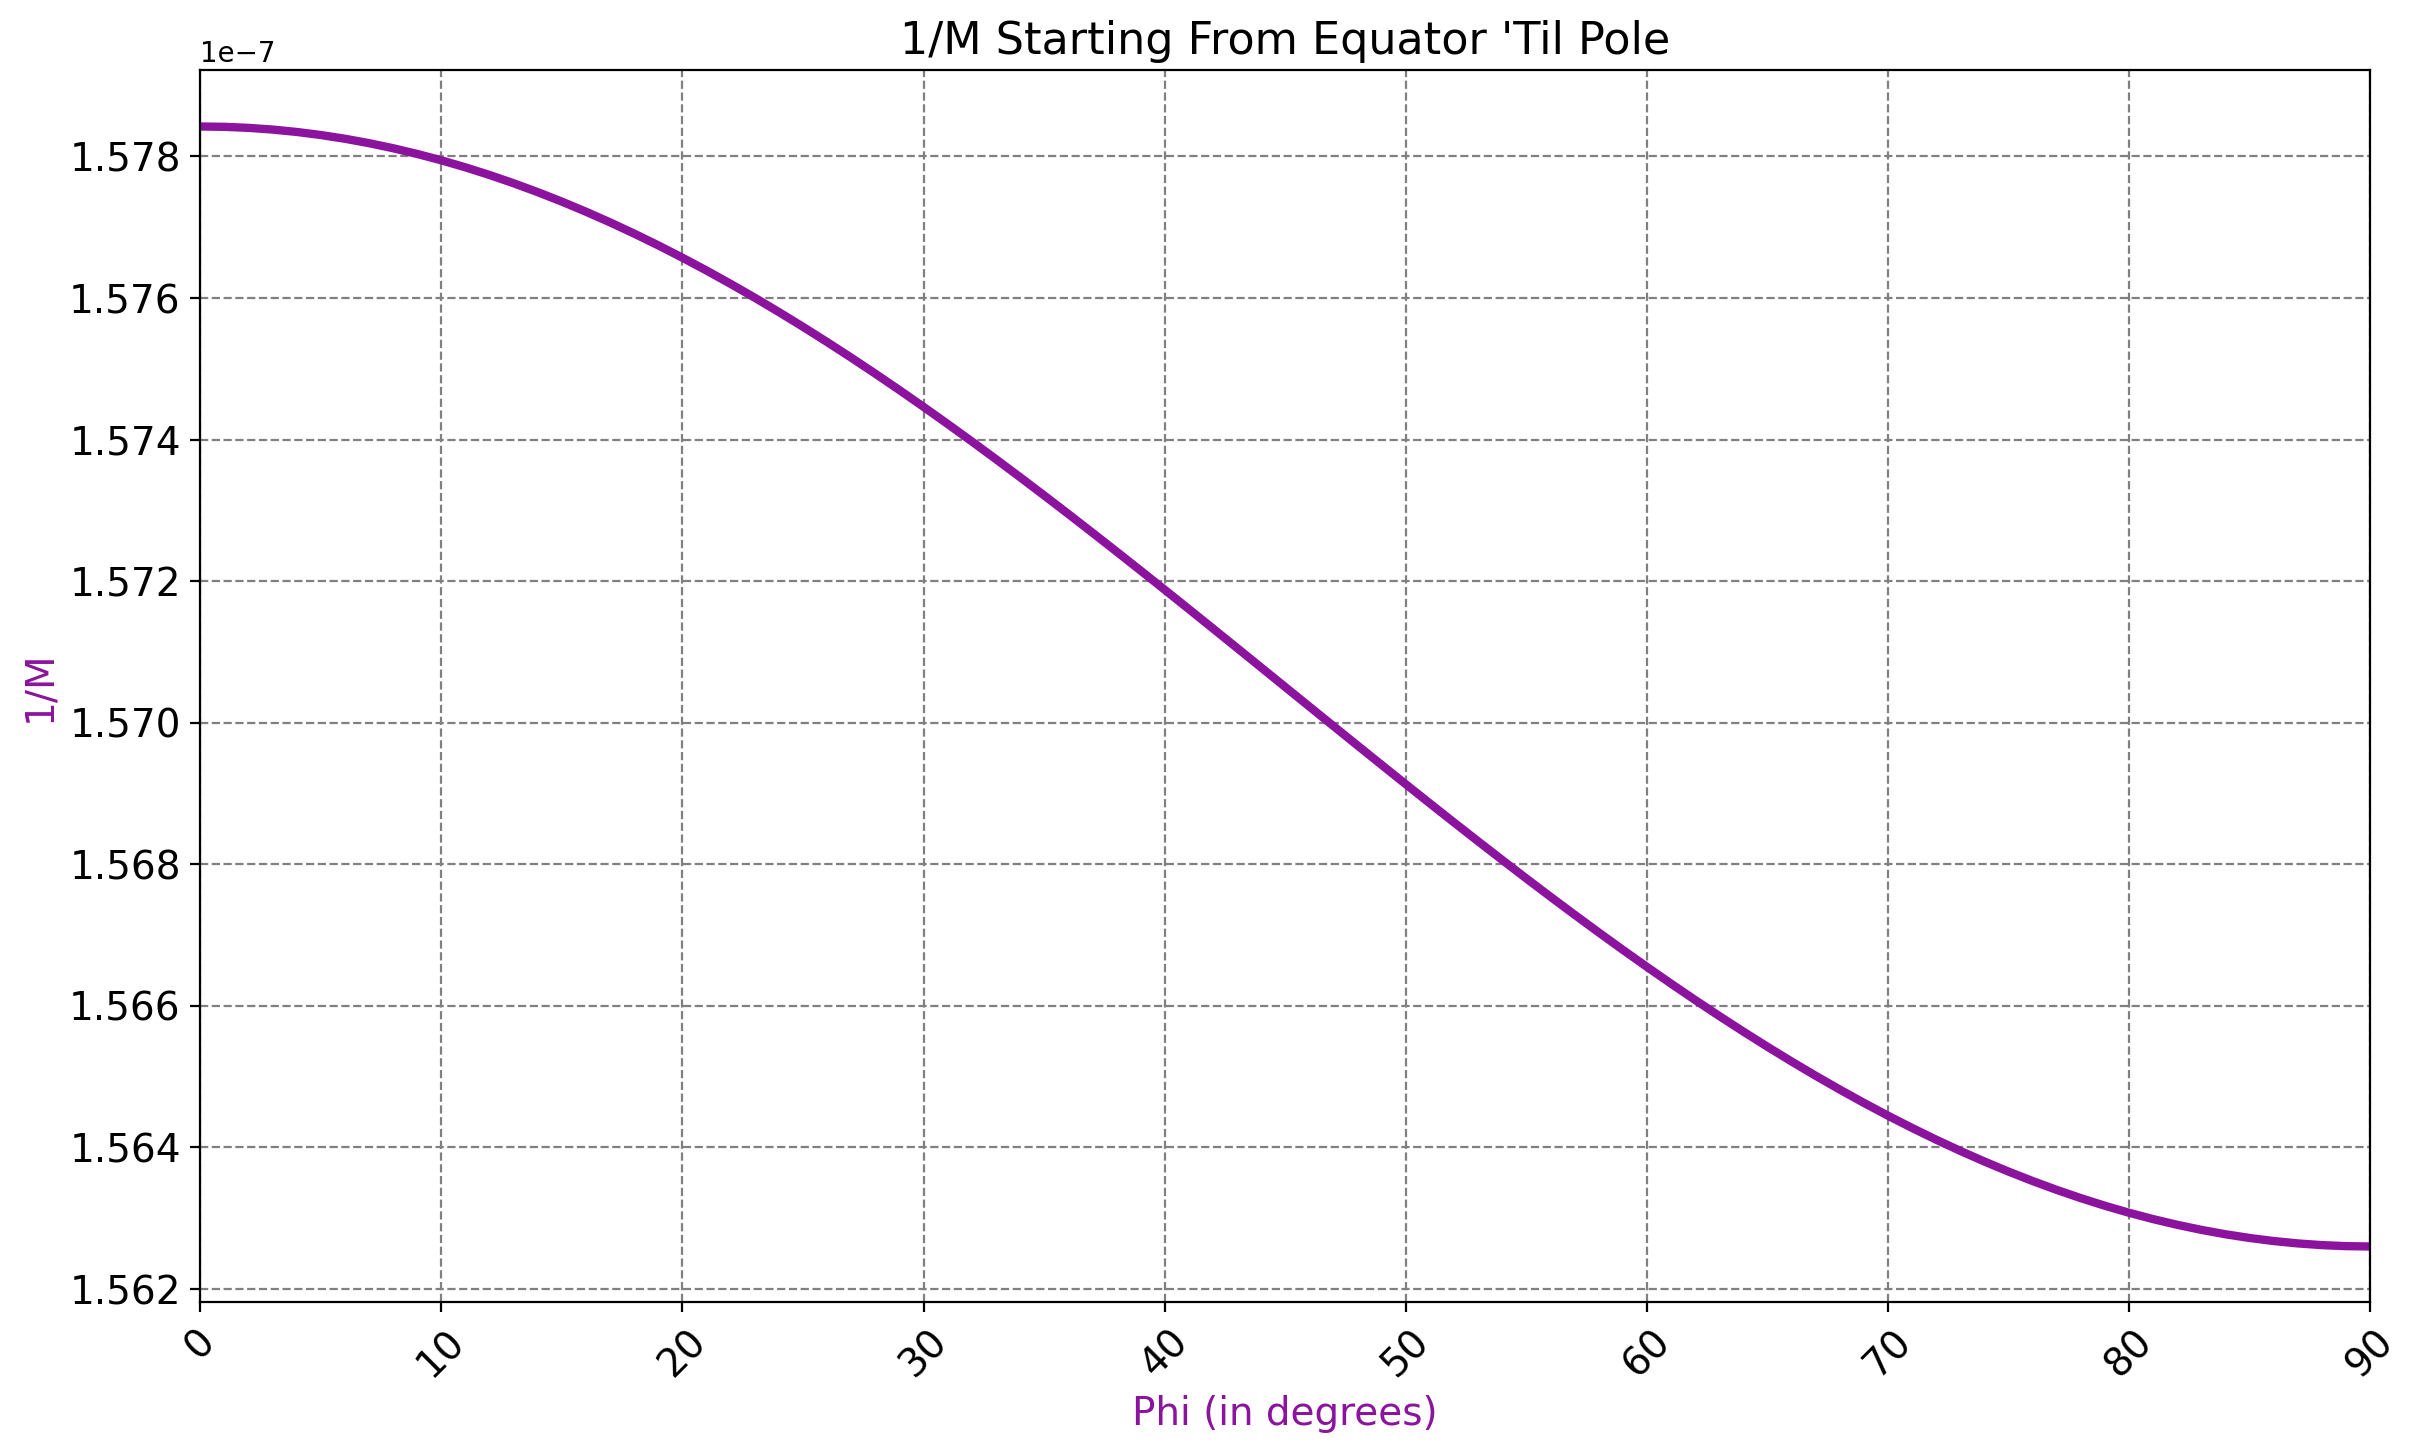

In [8]:
plt.figure(figsize=(14, 8), dpi=200)
plt.title("1/M Starting From Equator 'Til Pole", fontsize=16)
plt.yticks(fontsize=14)
plt.xticks(fontsize=14, rotation=45)

ax1 = plt.gca() # get current axis

ax1.set_ylabel("1/M", color="#8B139D", fontsize=14)
ax1.set_xlabel("Phi (in degrees)", color="#8B139D", fontsize=14)

ax1.set_xlim([min(phis), max(phis)])

ax1.grid(color="grey", linestyle="--")
ax1.plot(phis, Curves_M, 
         color="#8B139D", linewidth=3)

plt.show()

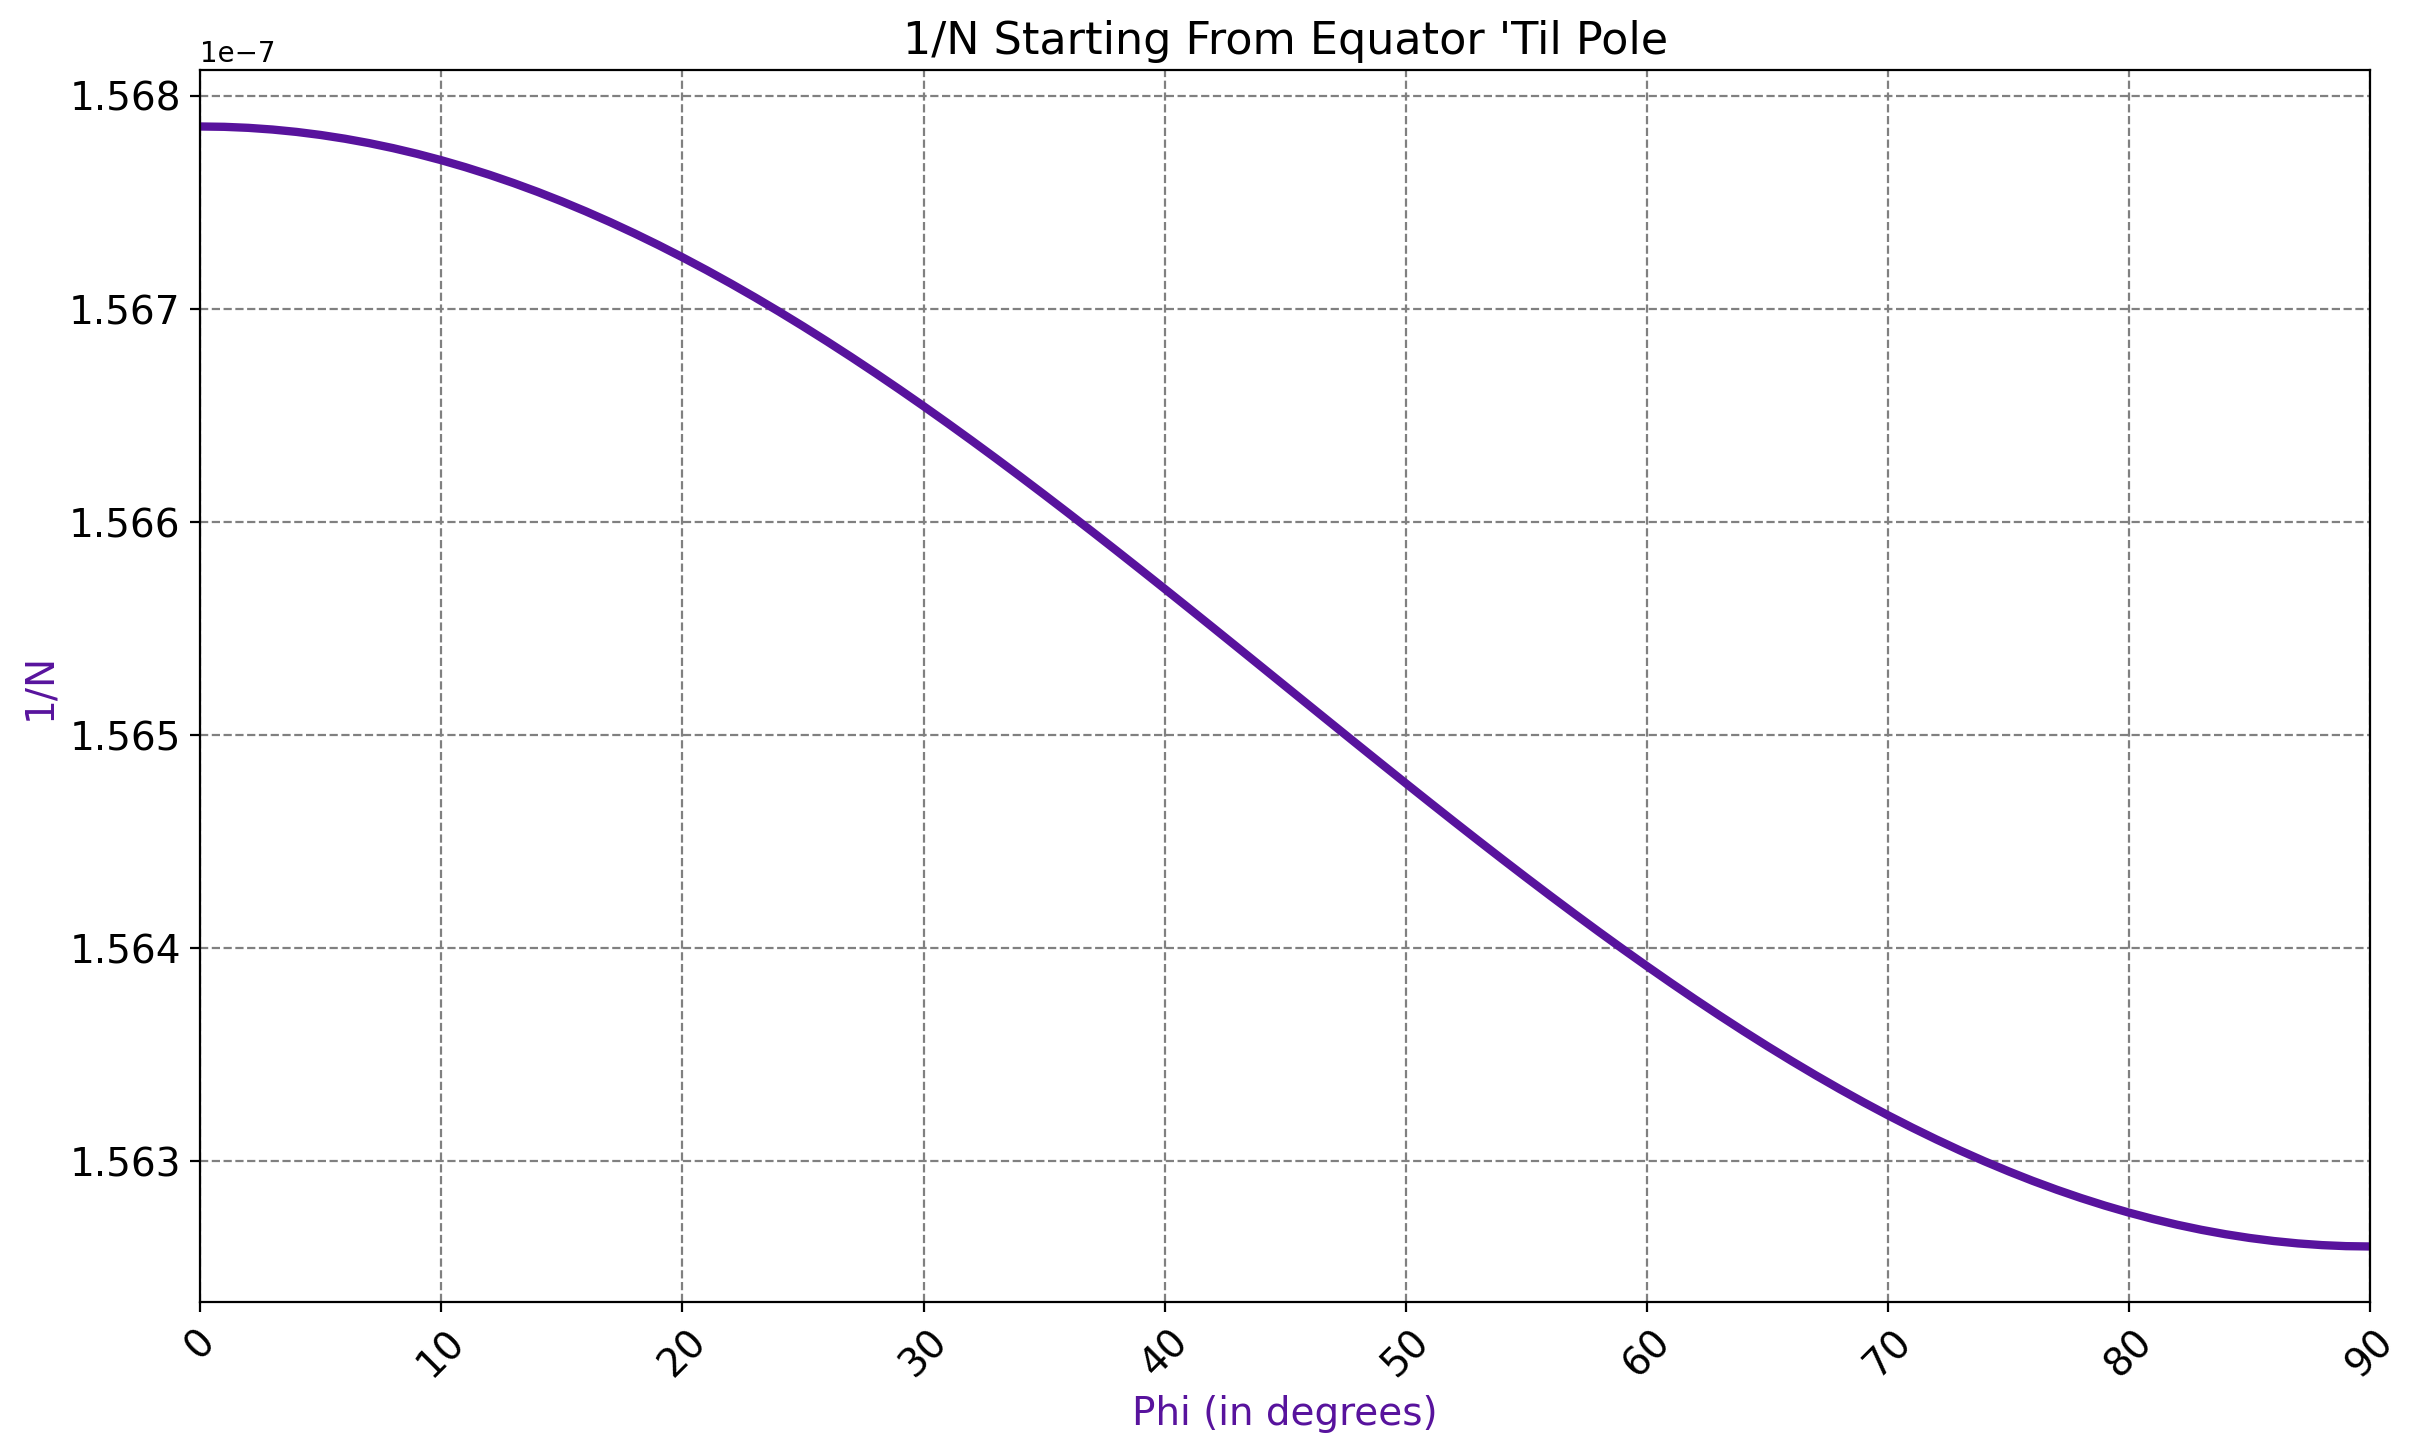

In [9]:
plt.figure(figsize=(14, 8), dpi=200)
plt.title("1/N Starting From Equator 'Til Pole", fontsize=16)
plt.yticks(fontsize=14)
plt.xticks(fontsize=14, rotation=45)

ax1 = plt.gca() # get current axis

ax1.set_ylabel("1/N", color="#58139D", fontsize=14)
ax1.set_xlabel("Phi (in degrees)", color="#58139D", fontsize=14)

ax1.set_xlim([min(phis), max(phis)])

ax1.grid(color="grey", linestyle="--")
ax1.plot(phis, Curves_N, 
         color="#58139D", linewidth=3)

plt.show()



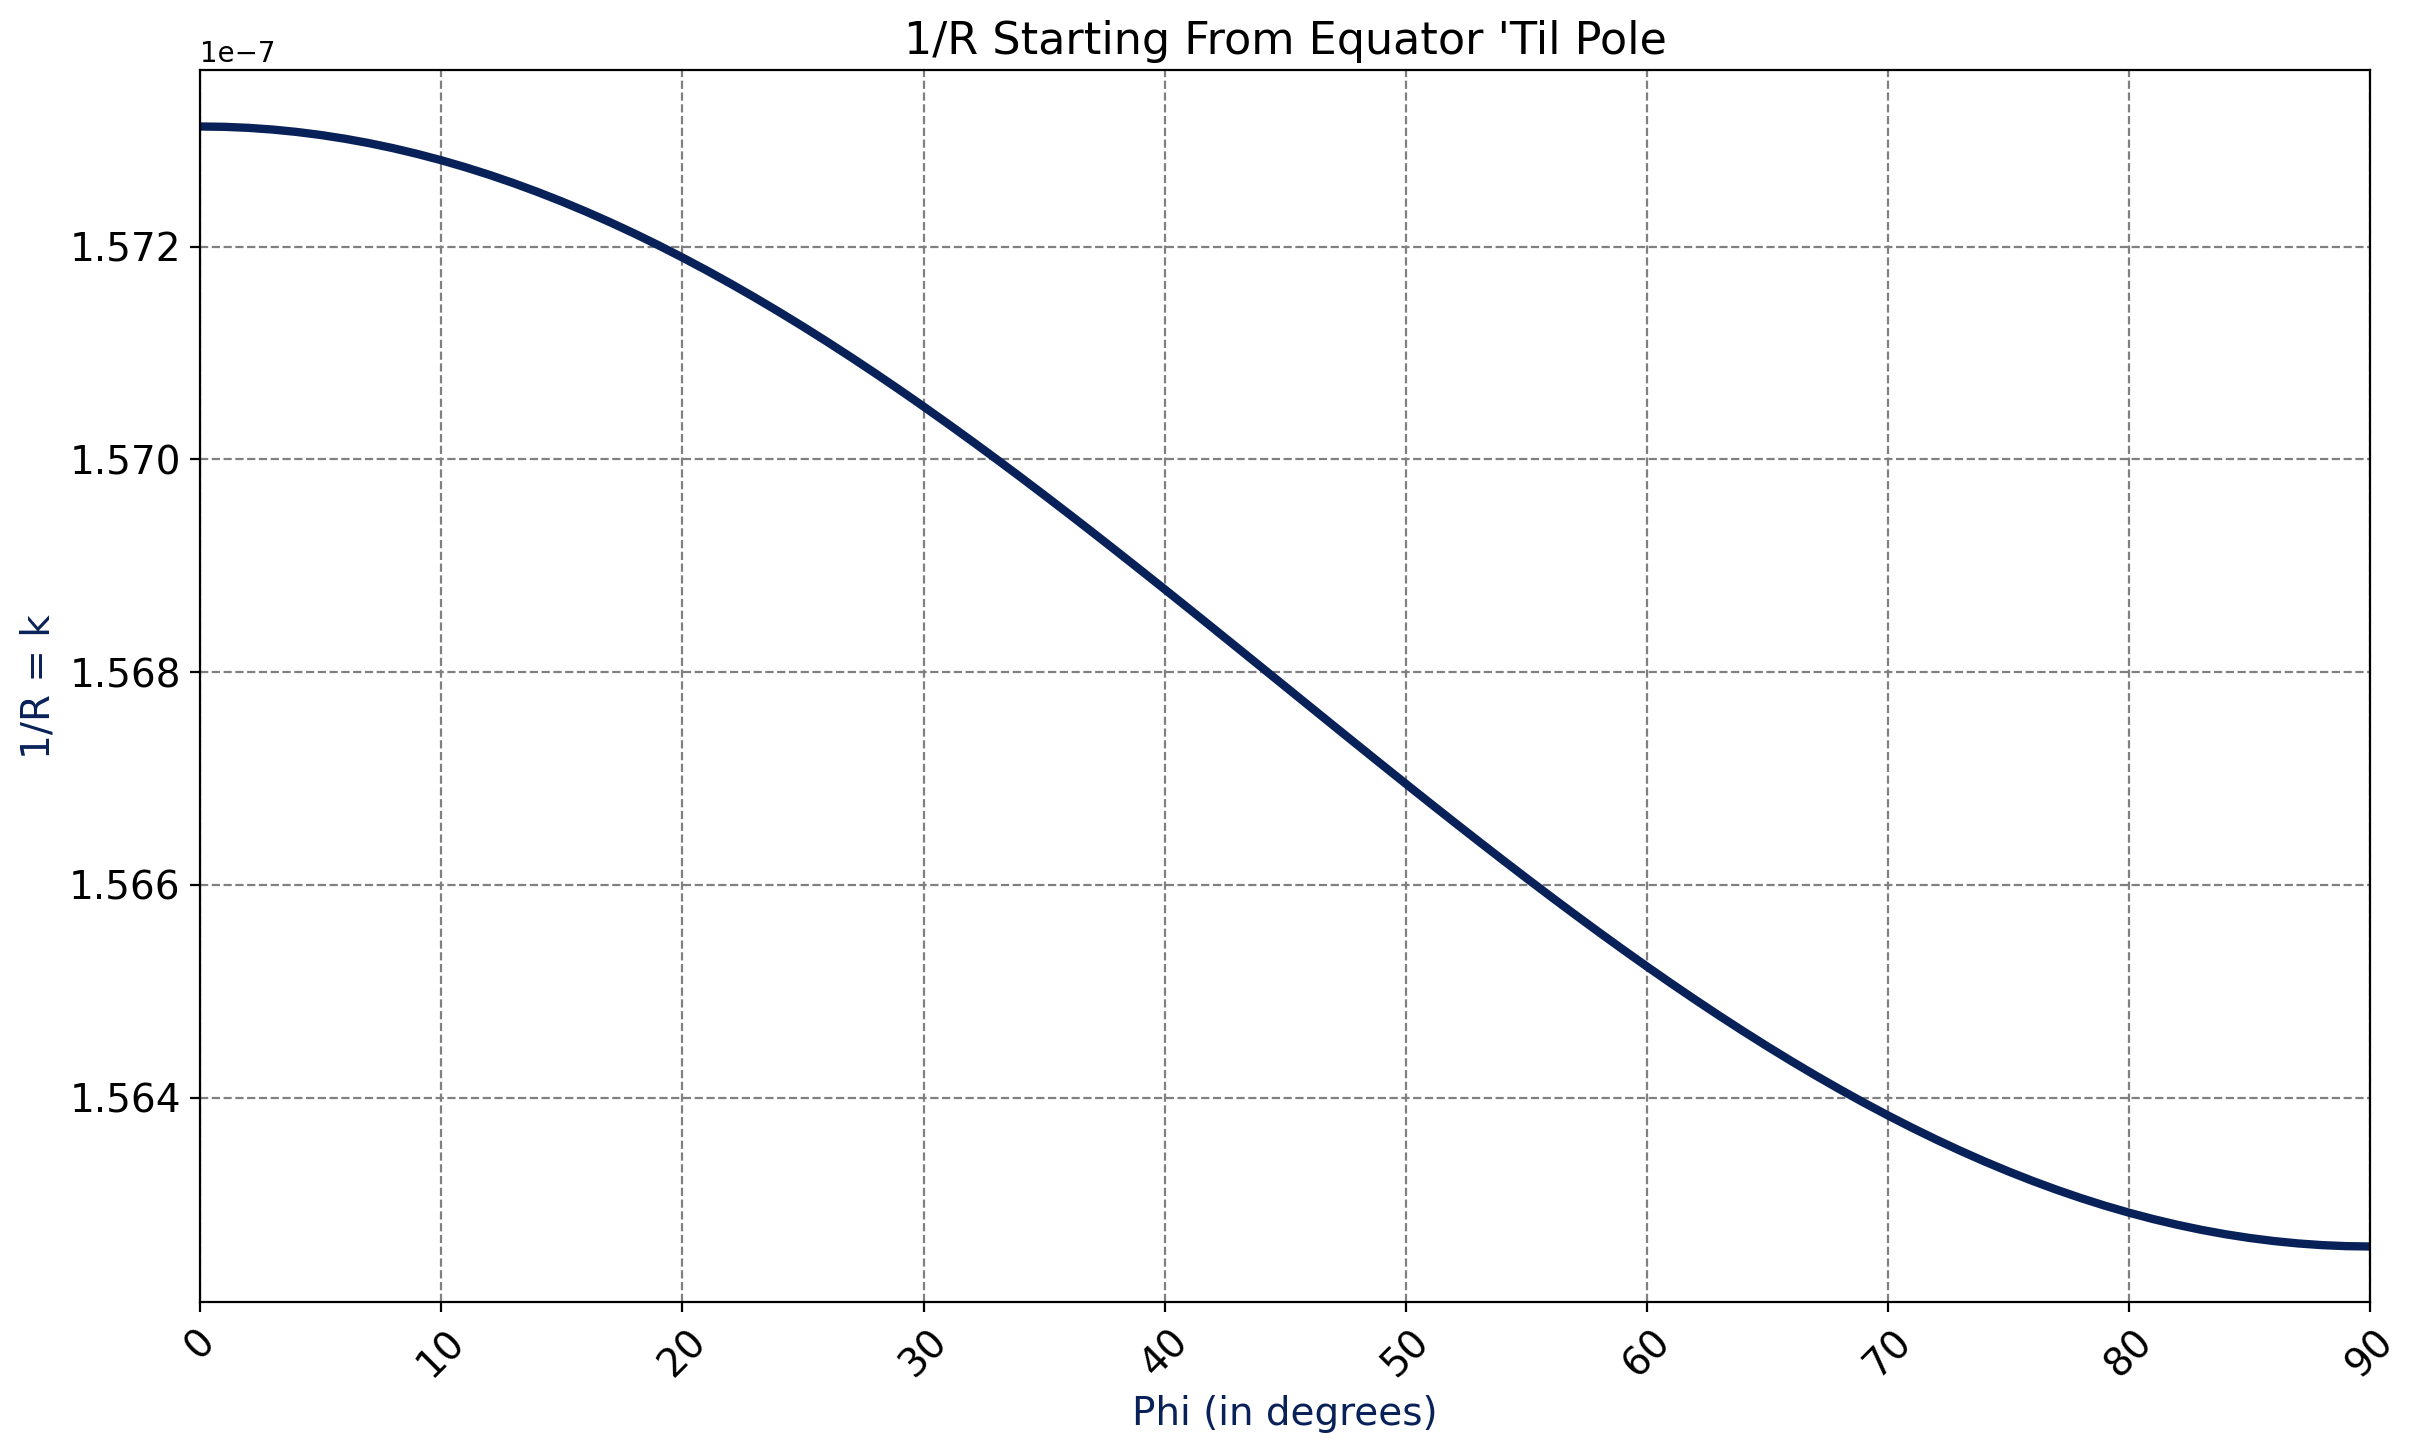

In [10]:
plt.figure(figsize=(14, 8), dpi=200)
plt.title("1/R Starting From Equator 'Til Pole", fontsize=16)
plt.yticks(fontsize=14)
plt.xticks(fontsize=14, rotation=45)

ax1 = plt.gca() # get current axis

ax1.set_ylabel("1/R = k", color="#082158", fontsize=14)
ax1.set_xlabel("Phi (in degrees)", color="#082158", fontsize=14)


ax1.set_xlim([min(phis), max(phis)])

ax1.grid(color="grey", linestyle="--")
ax1.plot(phis, Curves_R, 
         color="#082158", linewidth=3)

plt.show()


<h2>M - N<h2>

In [11]:
r_differences = [(M(phi) - N(phi)) for phi in phis]

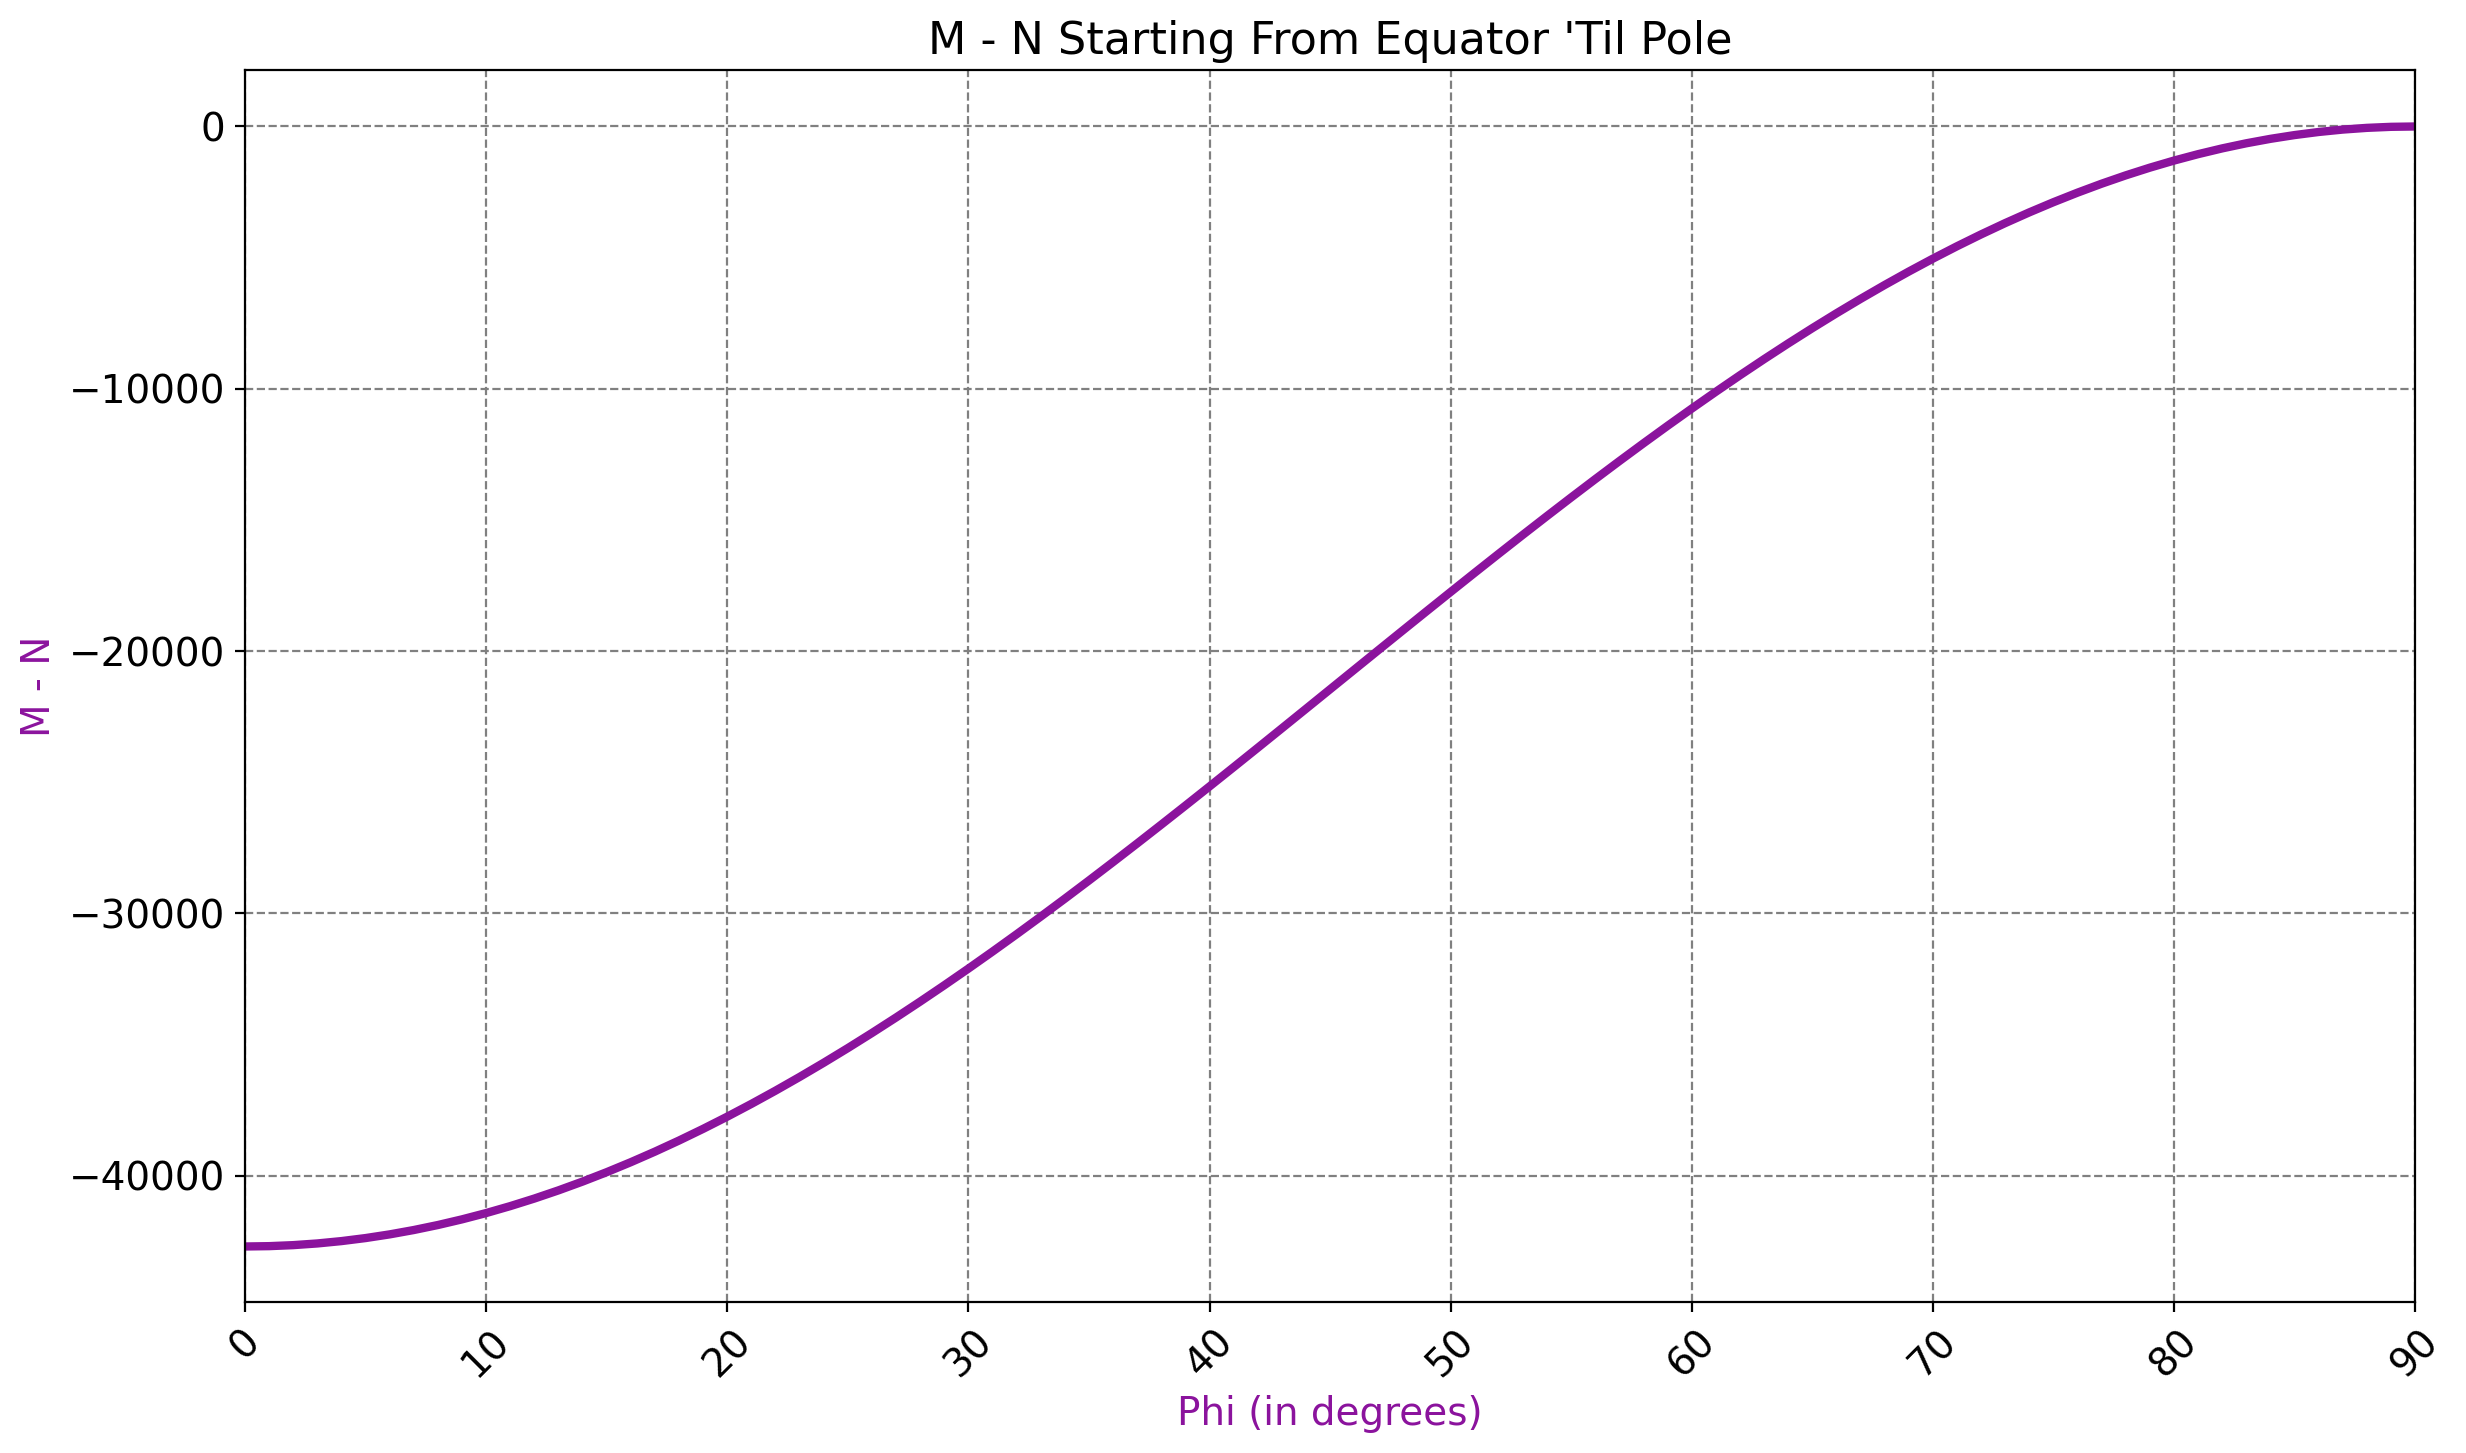

In [12]:
plt.figure(figsize=(14, 8), dpi=200)
plt.title("M - N Starting From Equator 'Til Pole", fontsize=16)
plt.yticks(fontsize=14)
plt.xticks(fontsize=14, rotation=45)

ax1 = plt.gca() # get current axis

ax1.set_ylabel("M - N", color="#8B139D", fontsize=14)
ax1.set_xlabel("Phi (in degrees)", color="#8B139D", fontsize=14)

ax1.set_xlim([min(phis), max(phis)])

ax1.grid(color="grey", linestyle="--")
ax1.plot(phis, r_differences, 
         color="#8B139D", linewidth=3)

plt.show()

<h2>R For Any Surface<h2>

In [14]:
def R_a(M, N, Az):
    Az = np.deg2rad(Az)
    return (M * N) / ((N * (cos(Az)**2)) + (M * (sin(Az)**2)))

In [15]:
Azs = list(range(0, 361))
R_as = np.zeros((len(phis), len(Azs)))

for i, phi in enumerate(phis):
    for j, Az in enumerate(Azs):
        R_as[i, j] = R_a(M(phi), N(phi), Az)

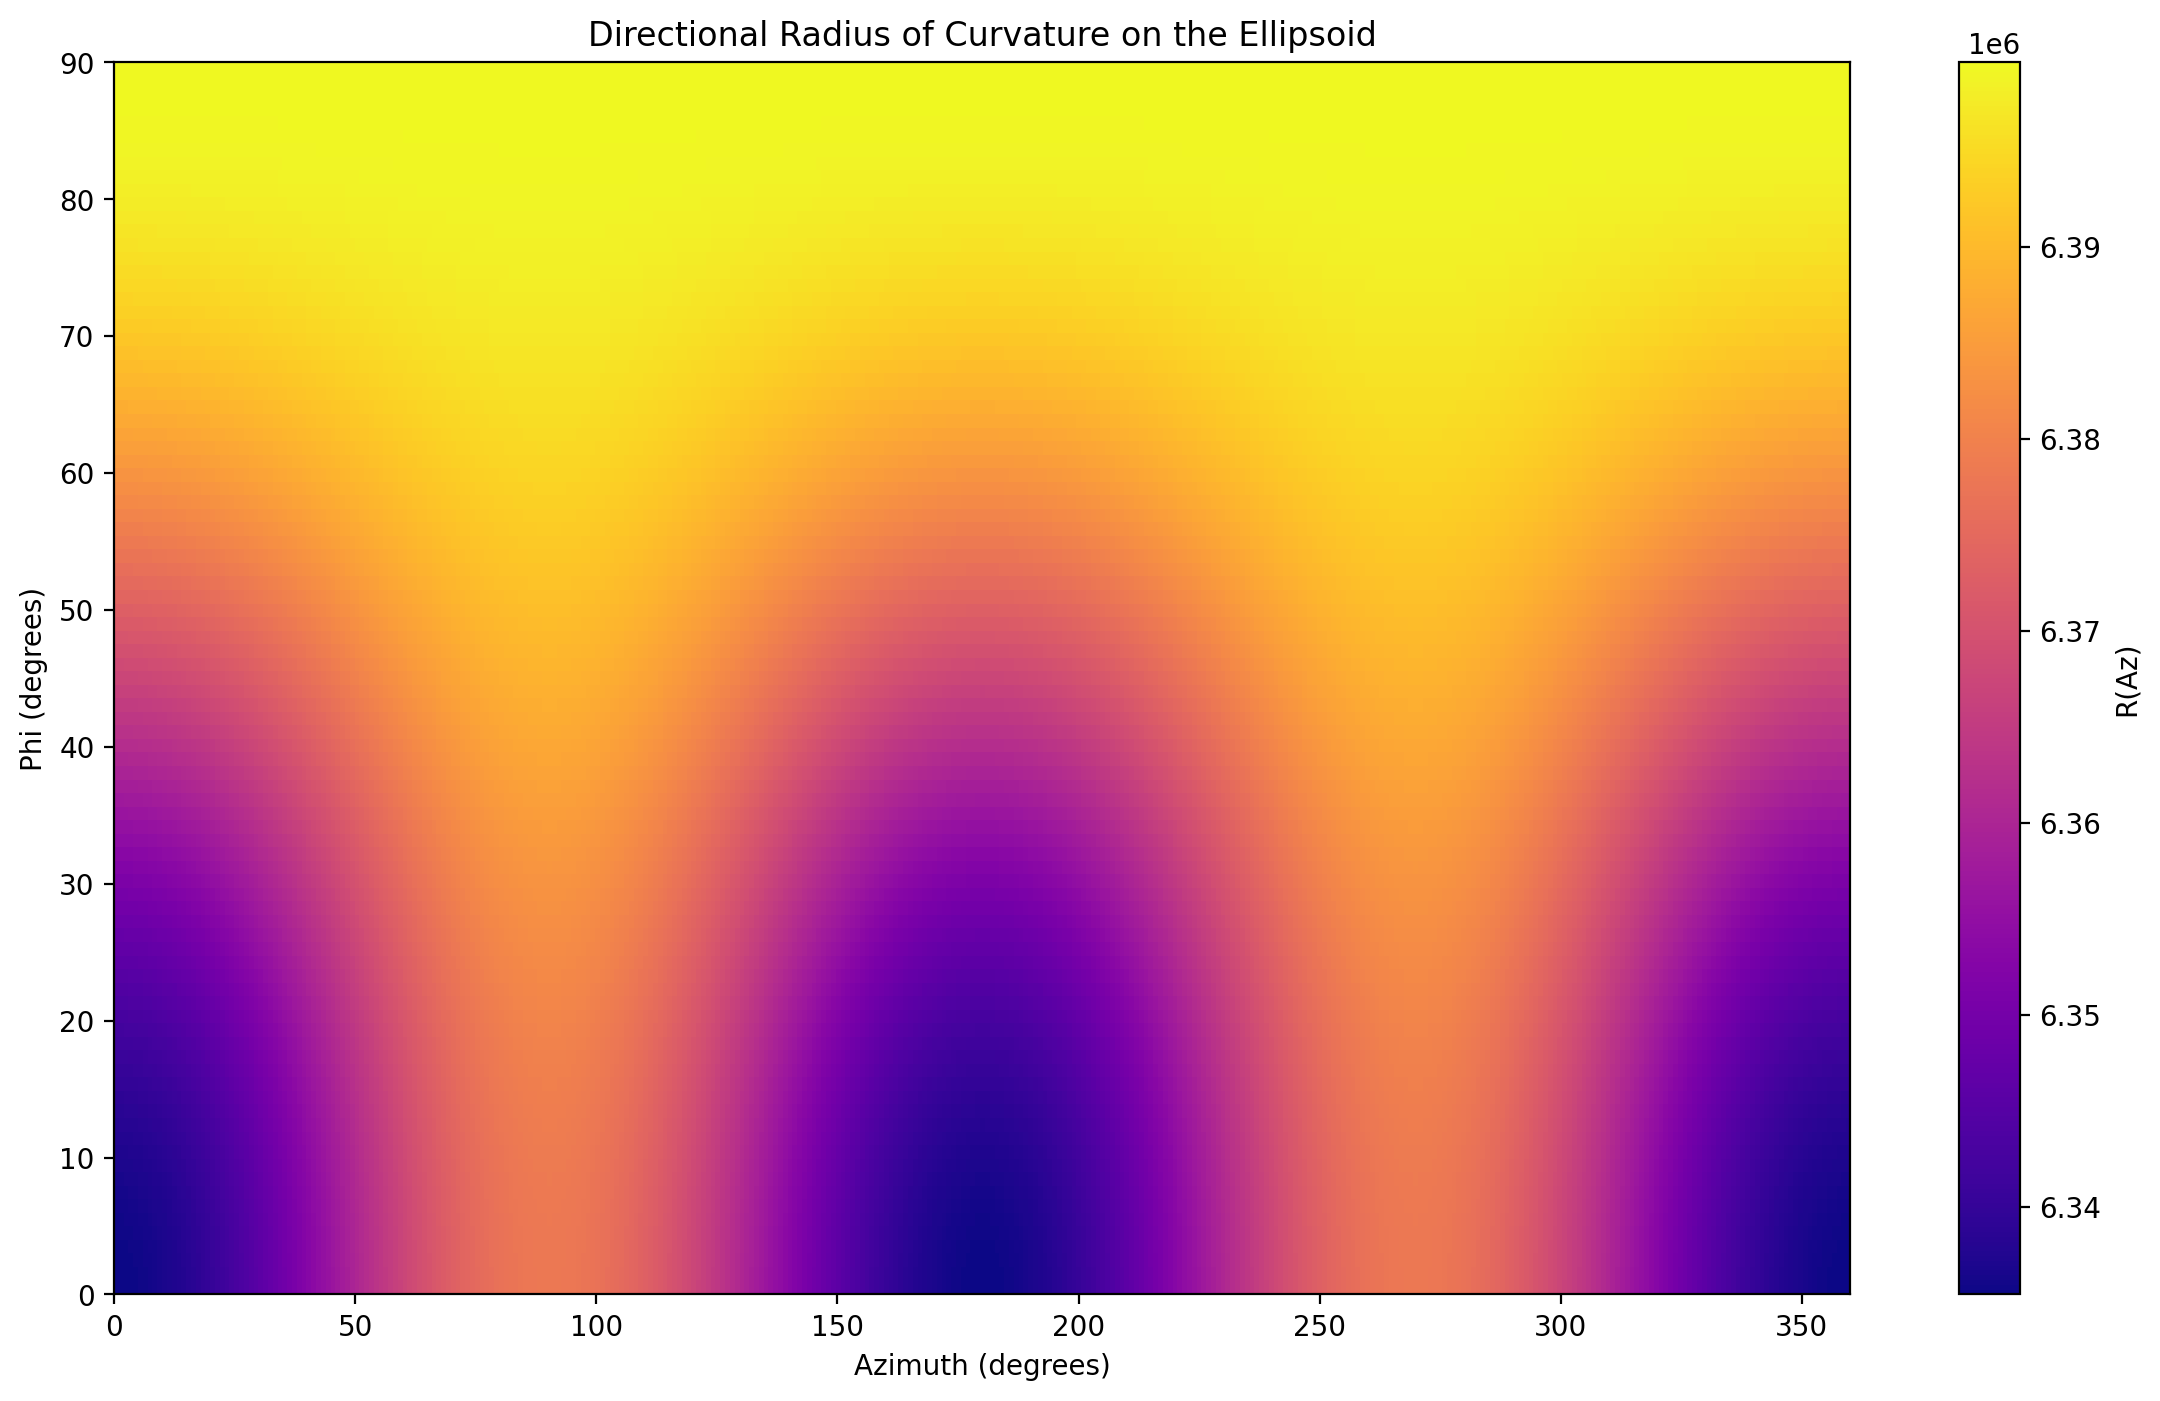

In [ ]:
plt.figure(figsize=(14, 8), dpi=200)

plt.imshow(
    R_as,
    extent=[0, 360, 0, 90],
    aspect="auto",
    origin="lower",
    cmap="plasma"
)

plt.colorbar(label="R(Az)")
plt.xlabel("Azimuth (degrees)")
plt.ylabel("Phi (degrees)")
plt.title("Directional Radius of Curvature on the Ellipsoid")

plt.show()


<h2>Flattening Of The Ellipsoid<h2>

In [17]:
def f(a, b):
    return (a - b) / a

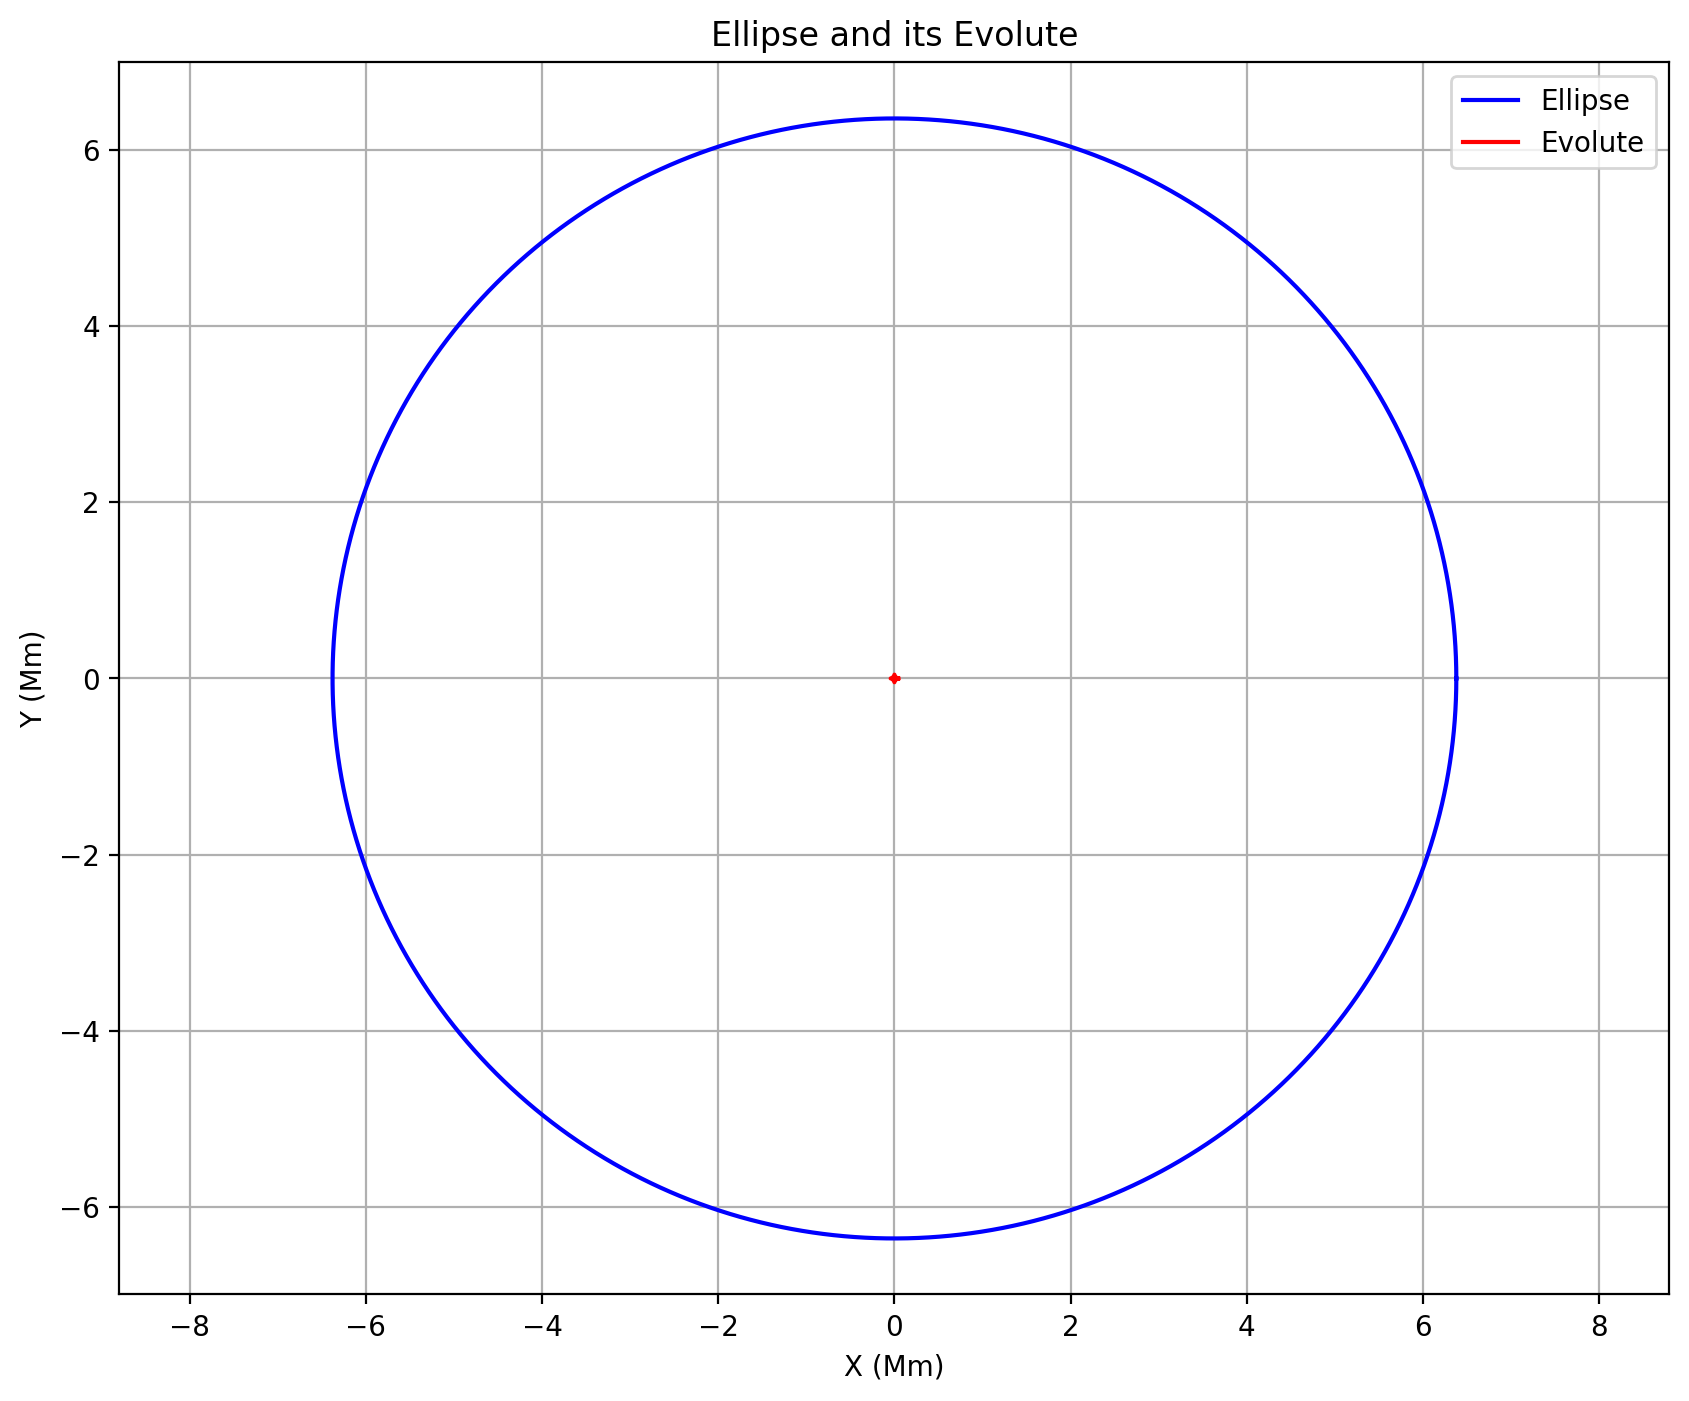

In [2]:
a = 6378137      
b = 6356752      

psi = np.linspace(0, 2*np.pi, 1000)

x_ellipse = a * np.cos(psi)
y_ellipse = b * np.sin(psi)

c = a**2 - b**2

x_evolute = (c / a) * np.cos(psi)**3
y_evolute = -(c / b) * np.sin(psi)**3

scale = 1e-6
x_evolute_scaled = x_evolute * scale
y_evolute_scaled = y_evolute * scale
x_ellipse_scaled = x_ellipse * scale
y_ellipse_scaled = y_ellipse * scale

plt.figure(figsize=(10, 8), dpi=200)
plt.plot(x_ellipse_scaled, y_ellipse_scaled, 'b', linewidth=1.5, label='Ellipse')
plt.plot(x_evolute_scaled, y_evolute_scaled, 'r', linewidth=1.5, label='Evolute')
plt.axis('equal')
plt.grid(True)
plt.xlabel('X (Mm)')
plt.ylabel('Y (Mm)')
plt.title('Ellipse and its Evolute')
plt.legend()
plt.show()
